In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/dark_patterns.csv')
df.head()

,page_id,text,label,Pattern Category
0,1012,FLASH SALE | LIMITED TIME ONLY Shop Now,1,Urgency
1,158,Pillowcases & Shams,0,Not Dark Pattern
2,108,Write a review,0,Not Dark Pattern
3,1425,"To start your return, simply click on the foll...",0,Not Dark Pattern
4,1658,newsletter signup (privacy policy),0,Not Dark Pattern


In [2]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (2356, 4)

Missing values:
 page_id             0
text                0
label               0
Pattern Category    0
dtype: int64

Data types:
 page_id              int64
text                object
label                int64
Pattern Category    object
dtype: object

Duplicate rows: 0


In [ ]:
import re
def clean_text(text):
    text = str(text).lower()           # lowercase
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z0-9\s]', '', text)  # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text
df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head(10)

,text,clean_text
0,FLASH SALE | LIMITED TIME ONLY Shop Now,flash sale limited time only shop now
1,Pillowcases & Shams,pillowcases shams
2,Write a review,write a review
3,"To start your return, simply click on the foll...",to start your return simply click on the follo...
4,newsletter signup (privacy policy),newsletter signup privacy policy
5,In demand,in demand
6,We cannot guarantee door to door delivery for ...,we cannot guarantee door to door delivery for ...
7,Hurry! Only 2 left in stock,hurry only 2 left in stock
8,In Stock only 3 left,in stock only 3 left
9,International Shipping Policy,international shipping policy


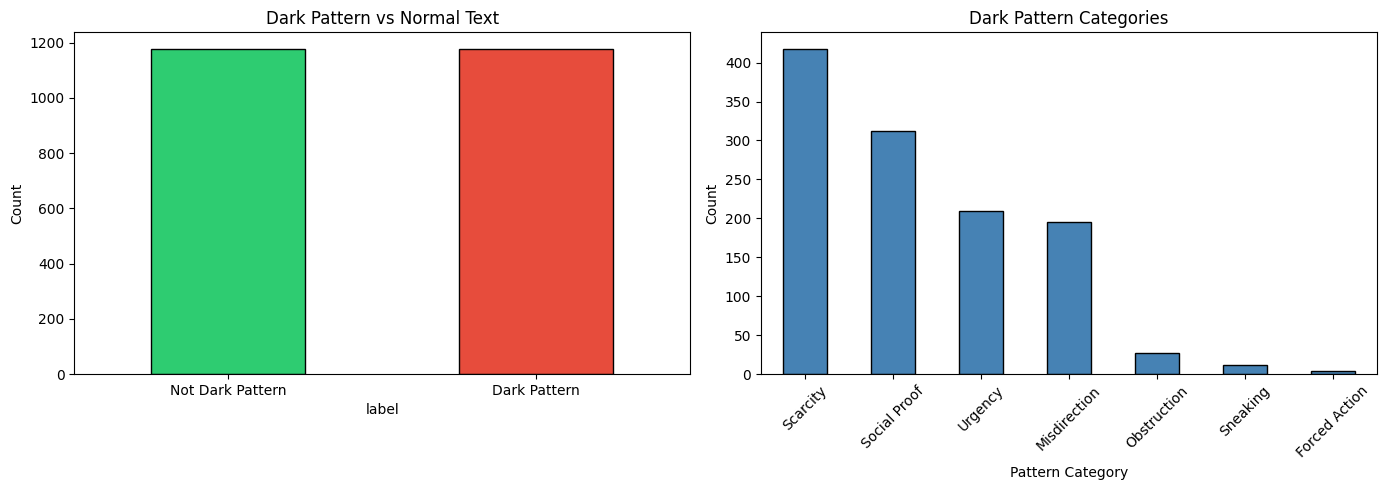

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1 - dark vs not dark
df['label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
    edgecolor='black'
)
axes[0].set_title('Dark Pattern vs Normal Text')
axes[0].set_xticklabels(['Not Dark Pattern', 'Dark Pattern'], rotation=0)
axes[0].set_ylabel('Count')

# plot 2 - category wise frq
dark_only = df[df['label'] == 1]
dark_only['Pattern Category'].value_counts().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Dark Pattern Categories')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/category_distribution.png', dpi=150)
plt.show()

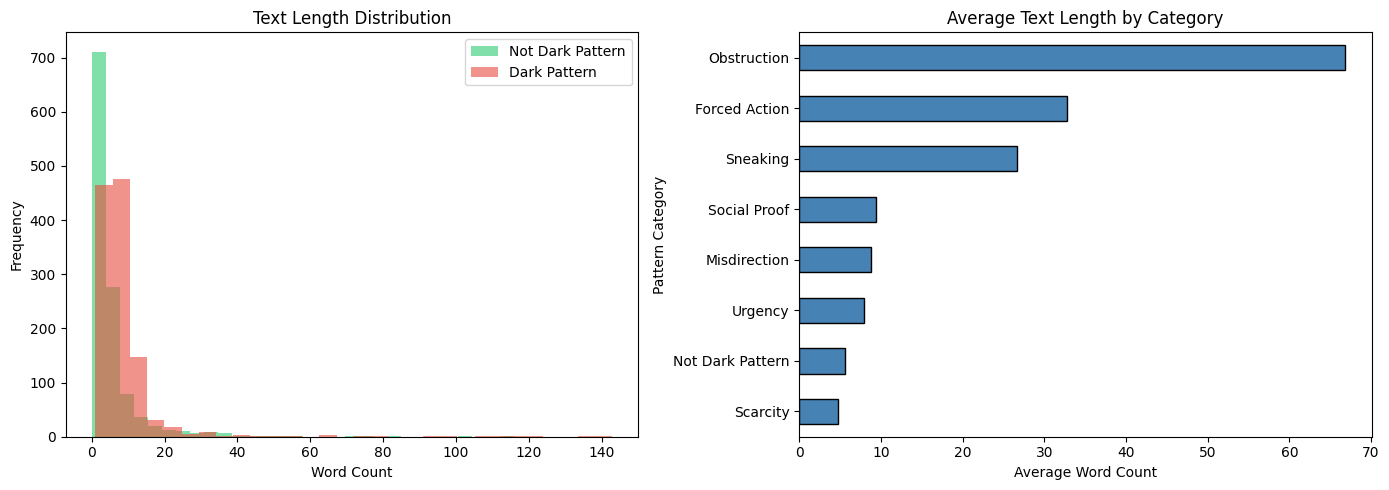

        count      mean        std  min  25%  50%  75%    max
label                                                        
0      1178.0  5.573854   8.810286  0.0  2.0  3.0  5.0  116.0
1      1178.0  8.977929  12.813790  1.0  4.0  6.0  9.0  143.0


In [ ]:
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1 - text length distribution
axes[0].hist(df[df['label']==0]['text_length'], bins=30, alpha=0.6, label='Not Dark Pattern', color='#2ecc71')
axes[0].hist(df[df['label']==1]['text_length'], bins=30, alpha=0.6, label='Dark Pattern', color='#e74c3c')
axes[0].set_title('Text Length Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# plot 2 - average length/category
df.groupby('Pattern Category')['text_length'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Average Text Length by Category')
axes[1].set_xlabel('Average Word Count')

plt.tight_layout()
plt.savefig('../data/text_length.png', dpi=150)
plt.show()

print(df.groupby('label')['text_length'].describe())

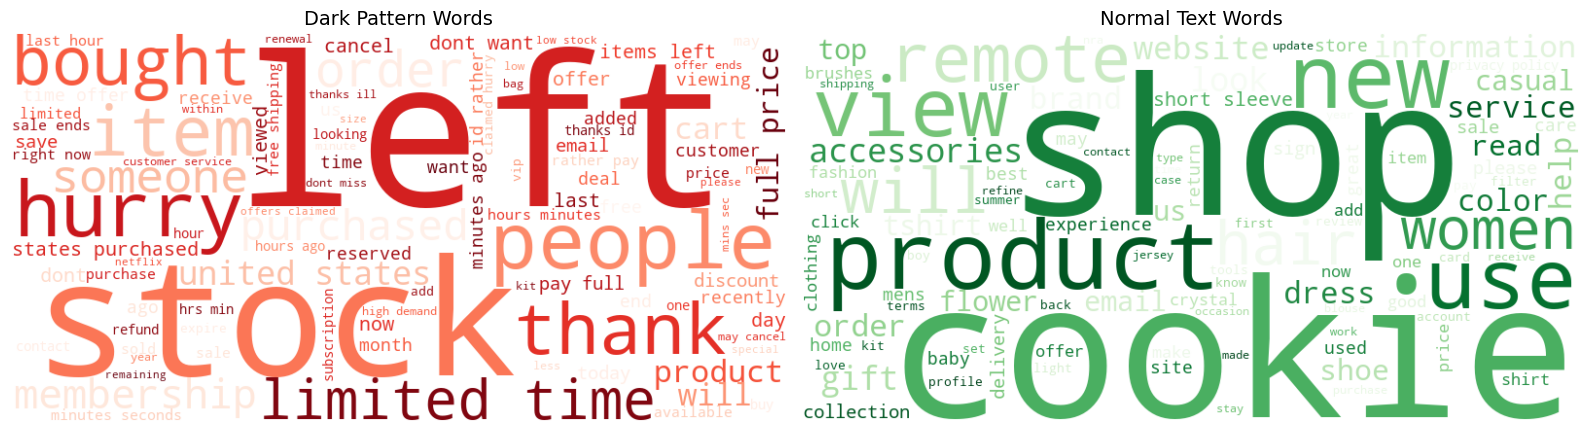

In [ ]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# for dark patterns
dark_text = ' '.join(df[df['label']==1]['clean_text'])
wc_dark = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds', max_words=100).generate(dark_text)
axes[0].imshow(wc_dark, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Dark Pattern Words', fontsize=14)

#  for normal text
normal_text = ' '.join(df[df['label']==0]['clean_text'])
wc_normal = WordCloud(width=800, height=400, background_color='white',
                      colormap='Greens', max_words=100).generate(normal_text)
axes[1].imshow(wc_normal, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Normal Text Words', fontsize=14)

plt.tight_layout()
plt.savefig('../data/wordcloud.png', dpi=150)
plt.show()

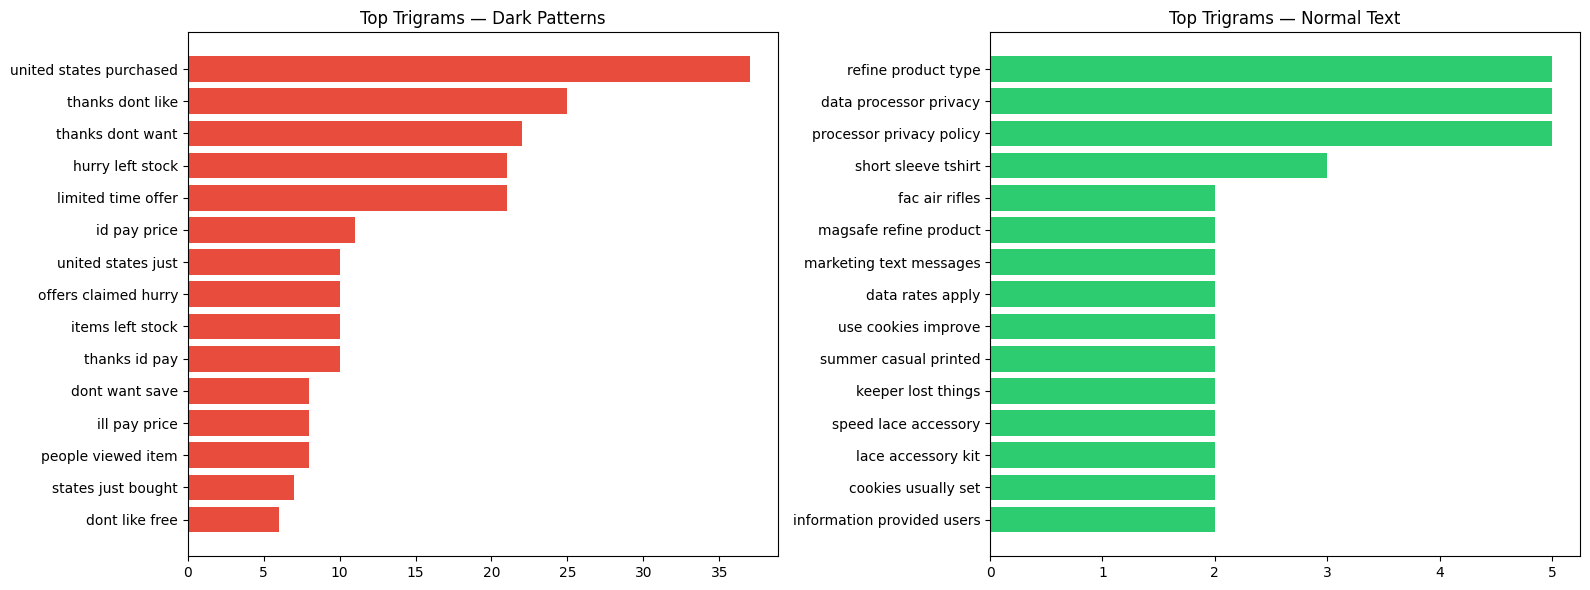

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=3, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag = vec.transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

dark_corpus = df[df['label']==1]['clean_text']
normal_corpus = df[df['label']==0]['clean_text']

dark_trigrams = get_top_ngrams(dark_corpus)
normal_trigrams = get_top_ngrams(normal_corpus)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# dark pattern trigrams
words, counts = zip(*dark_trigrams)
axes[0].barh(words, counts, color='#e74c3c')
axes[0].set_title('Top Trigrams — Dark Patterns')
axes[0].invert_yaxis()

# normal trigrams
words, counts = zip(*normal_trigrams)
axes[1].barh(words, counts, color='#2ecc71')
axes[1].set_title('Top Trigrams — Normal Text')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/trigrams.png', dpi=150)
plt.show()